In [10]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

In [ ]:
def concat_losses(df_folder):
    csv_files = glob.glob(os.path.join(df_folder, '*.csv'))

    df_list = []
    for file in csv_files:
        df = pd.read_csv(file)
        df['source'] = os.path.basename(file)
        df_list.append(df)

    combined_df = pd.concat(df_list, ignore_index=True)

    return combined_df

In [17]:
def draw_loss_graph(df):
    for name, group in df.groupby('source'):
        plt.plot(group['Step'], group['Value'], label=name)

    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()
    plt.show()

In [18]:
df = concat_losses("train-data/eval-loss")
df.head()

,Wall time,Step,Value,source
0,1.749339e+09,200,0.221290,finetune_4.csv
1,1.749339e+09,400,0.191848,finetune_4.csv
2,1.749340e+09,600,0.175166,finetune_4.csv
3,1.749341e+09,800,0.164778,finetune_4.csv
4,1.749341e+09,1000,0.156416,finetune_4.csv


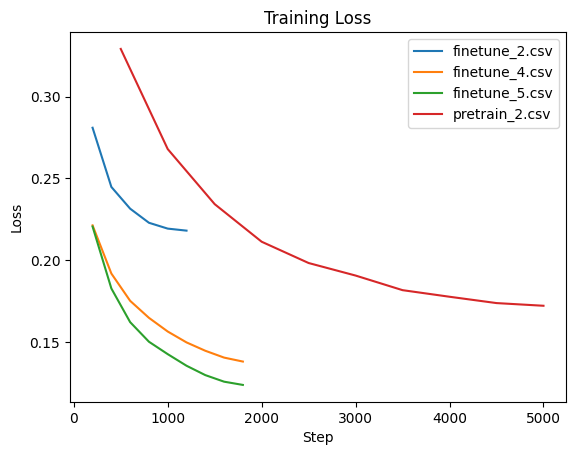

In [19]:
draw_loss_graph(df)

In [2]:
df = pd.read_csv("train-data/eval-loss/finetune_5.csv")
df

,Wall time,Step,Value
0,1.749346e+09,200,0.220562
1,1.749347e+09,400,0.182725
2,1.749347e+09,600,0.162146
3,1.749348e+09,800,0.150172
4,1.749349e+09,1000,0.142587
5,1.749349e+09,1200,0.135501
6,1.749350e+09,1400,0.129777
7,1.749351e+09,1600,0.125762
8,1.749351e+09,1800,0.123781


In [ ]:
train_folder = 'train-data/train-loss'
eval_folder = 'train-data/eval-loss'

train_files = glob.glob(os.path.join(train_folder, '*.csv'))
eval_files = glob.glob(os.path.join(eval_folder, '*.csv'))

def read_csvs(files):
    dfs = []
    for file in files:
        df = pd.read_csv(file)
        df['filename'] = os.path.basename(file)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

train_df = read_csvs(train_files)
eval_df  = read_csvs(eval_files)


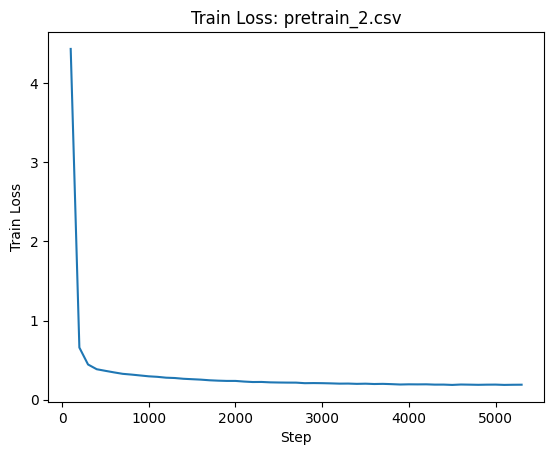

In [ ]:
plt.figure()
pretrain_train = train_df[train_df['filename'] == 'pretrain_2.csv']
plt.plot(pretrain_train['Step'], pretrain_train['Value'])
plt.xlabel('Step')
plt.ylabel('Train Loss')
plt.title('Train Loss: pretrain_2.csv')
plt.show()

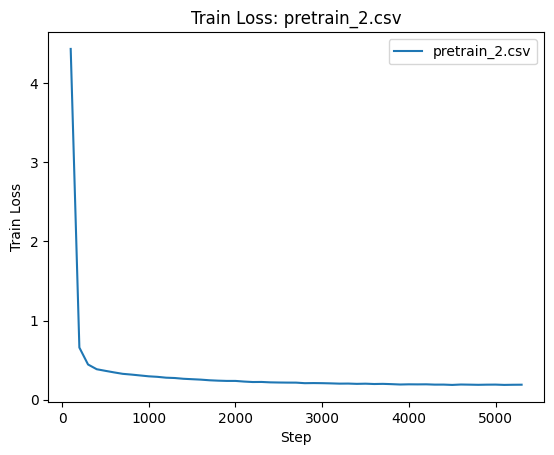

In [24]:
plt.figure()
pretrain_train = train_df[train_df['filename'] == 'pretrain_2.csv']
plt.plot(pretrain_train['Step'], pretrain_train['Value'], label='pretrain_2.csv')
plt.xlabel('Step')
plt.ylabel('Train Loss')
plt.title('Train Loss: pretrain_2.csv')
plt.legend()
plt.show()

In [ ]:
train_df = train_df[train_df.Step >= 200]
train_df

,Wall time,Step,Value,filename
3,1.749339e+09,200,0.2491,finetune_4.csv
4,1.749339e+09,250,0.2420,finetune_4.csv
5,1.749339e+09,300,0.2268,finetune_4.csv
6,1.749339e+09,350,0.2203,finetune_4.csv
7,1.749339e+09,400,0.2133,finetune_4.csv
...,...,...,...,...
158,1.749295e+09,800,0.2515,finetune_2.csv
159,1.749295e+09,900,0.2440,finetune_2.csv
160,1.749296e+09,1000,0.2460,finetune_2.csv
161,1.749296e+09,1100,0.2424,finetune_2.csv


In [58]:
train_df.filename.unique()

array(['finetune_4.csv', 'pretrain_2.csv', 'pretrain.csv',
       'finetune_5.csv', 'finetune_2.csv'], dtype=object)

In [57]:
eval_df = eval_df[eval_df.Step >= 200]

In [44]:
import numpy as np

finetune_2.csv


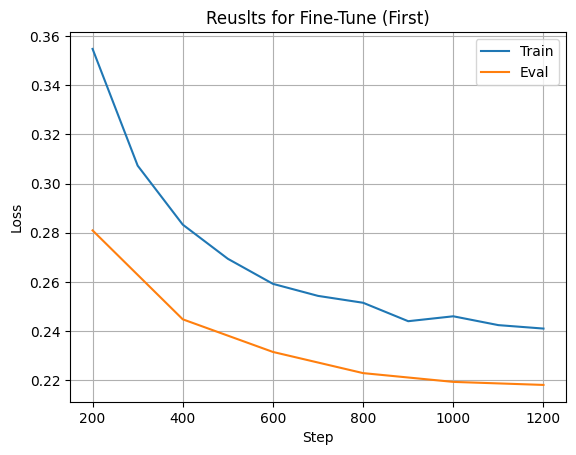

finetune_4.csv


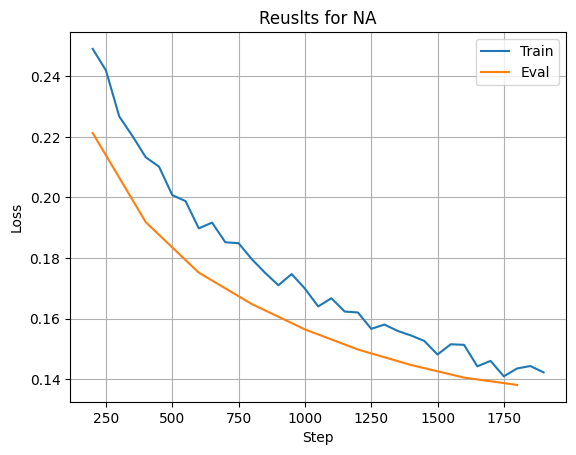

finetune_5.csv


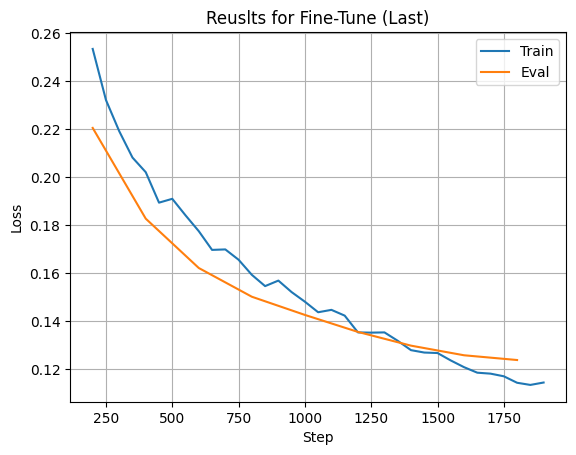

pretrain.csv


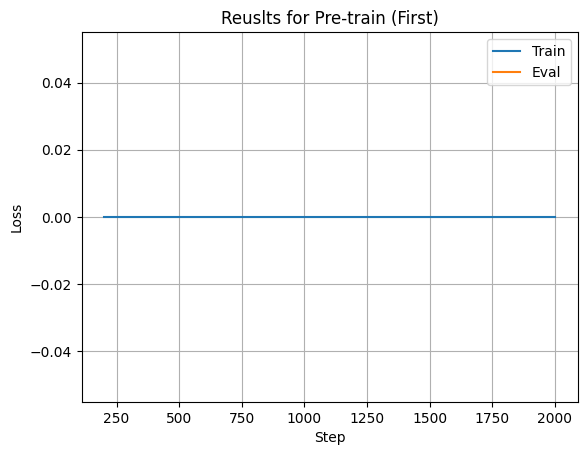

pretrain_2.csv


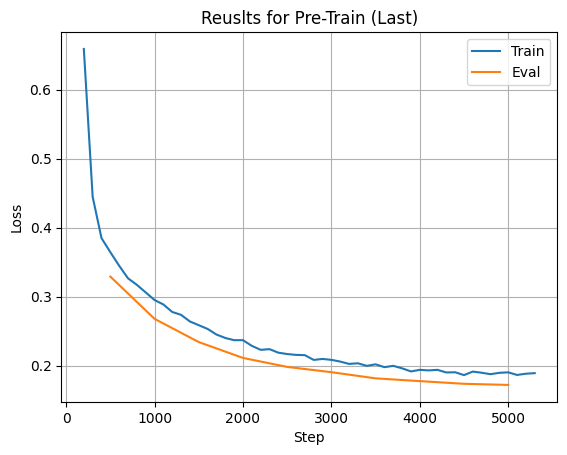

In [ ]:
all_files = set(train_df['filename']).union(set(eval_df['filename']))

for fname in sorted(all_files):
    plt.figure()
    # Train
    train_group = train_df[train_df['filename'] == fname]
    if not train_group.empty:
        plt.plot(train_group['Step'], train_group['Value'], label='Train')
    # Eval
    eval_group = eval_df[eval_df['filename'] == fname]
    if not eval_group.empty:
        plt.plot(eval_group['Step'], eval_group['Value'], label='Eval')
    # Оформление
    plt.xlabel('Step')
    plt.ylabel('Loss')
    print(fname)
    if fname.startswith("pretrain"):
        if fname == "pretrain.csv": postfix = "Pre-train (First)"
        else: postfix = "Pre-Train (Last)"
    else:
        if "2" in fname: postfix = "Fine-Tune (First)"
        elif "5" in fname: postfix = "Fine-Tune (Last)"
        else: postfix = "NA"
    plt.title(f'Reuslts for {postfix}')
    plt.legend()
    plt.grid()
    plt.show()